# Exploratory Data Analysis

This notebook explores historical demand patterns in the M5 Walmart
Forecasting dataset at the store-category level.

The analysis focuses on:

- demand distribution across categories, stores, and states
- demand trends over time
- weekly and seasonal patterns
- event and SNAP effects
- price-demand relationships
- differences in demand behavior across individual time series

The findings will guide feature engineering, validation design,
and model selection.

In [59]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

In [60]:
PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [61]:
from src.data.load_data import load_m5_data
from src.data.preprocess import preprocess_m5_data

In [62]:
DATA_DIR = PROJECT_ROOT / "data" / "raw"

sales, calendar, prices = load_m5_data(DATA_DIR)

data = preprocess_m5_data(
    sales,
    calendar,
    prices,
)

## 1. Dataset Overview

Before analyzing demand patterns, we verify the structure, time coverage,
and completeness of the modeling dataset.

In [63]:
print(f"Shape: {data.shape}")

print(
    f"Date range: {data['date'].min().date()} "
    f"to {data['date'].max().date()}"
)

print(
    "Number of store-category series:",
    data[
        ["store_id", "cat_id"]
    ].drop_duplicates().shape[0],
)

print(f"Number of stores: {data['store_id'].nunique()}")
print(f"Number of states: {data['state_id'].nunique()}")
print(f"Number of categories: {data['cat_id'].nunique()}")

Shape: (58230, 19)
Date range: 2011-01-29 to 2016-05-22
Number of store-category series: 30
Number of stores: 10
Number of states: 3
Number of categories: 3


In [64]:
missing_summary = (
    data.isna()
    .sum()
    .to_frame("missing_count")
)

missing_summary["missing_pct"] = (
    missing_summary["missing_count"]
    / len(data)
    * 100
)

missing_summary[
    missing_summary["missing_count"] > 0
].sort_values(
    "missing_pct",
    ascending=False,
)

,missing_count,missing_pct
event_name_2,58110,99.793921
event_type_2,58110,99.793921
event_name_1,53490,91.859866
event_type_1,53490,91.859866


### Missing-value findings

Missing values are limited to the calendar event variables. Approximately
91.9% of observations have no primary event and 99.8% have no secondary
event.

These missing values represent the absence of a scheduled event rather than
a data-quality issue. Therefore, observations with missing event information
are retained. Event presence will be represented explicitly during feature
engineering.

## 2. Demand Distribution

We first examine the distribution of daily sales to understand the scale,
variability, sparsity, and potential skewness of the forecasting target.

In [65]:
data["sales"].describe()

count    58230.000000
mean      1149.358973
std       1053.134745
min          0.000000
25%        356.000000
50%        706.000000
75%       1742.000000
max       6488.000000
Name: sales, dtype: float64

In [66]:
zero_sales_pct = (
    data["sales"].eq(0).mean() * 100
)

print(
    f"Zero-demand observations: "
    f"{zero_sales_pct:.2f}%"
)

Zero-demand observations: 0.21%


### Demand distribution findings

Daily demand varies substantially across the store-category series. Average
daily sales are approximately 1,149 units, compared with a median of 706
units, indicating a right-skewed distribution with periods of relatively high
demand.

Only 0.21% of store-category-day observations have zero sales. At this
aggregation level, demand is therefore largely continuous rather than
intermittent, which supports the use of standard regression-based forecasting
methods rather than methods designed specifically for intermittent demand.

In [67]:
category_summary = (
    data
    .groupby(
        "cat_id",
        observed=True,
    )["sales"]
    .agg(
        total_sales="sum",
        mean_daily_sales="mean",
        median_daily_sales="median",
        std_daily_sales="std",
        max_daily_sales="max",
    )
    .sort_values(
        "total_sales",
        ascending=False,
    )
)

category_summary

,total_sales,mean_daily_sales,median_daily_sales,std_daily_sales,max_daily_sales
cat_id,,,,,
FOODS,45922427,2365.915868,2215.0,928.250134,6488
HOUSEHOLD,14764090,760.643483,701.0,362.395537,2724
HOBBIES,6240656,321.517568,298.0,133.651295,956


In [68]:
category_summary["sales_share_pct"] = (
    category_summary["total_sales"]
    / category_summary["total_sales"].sum()
    * 100
)

category_summary.round(2)

,total_sales,mean_daily_sales,median_daily_sales,std_daily_sales,max_daily_sales,sales_share_pct
cat_id,,,,,,
FOODS,45922427,2365.92,2215.0,928.25,6488,68.62
HOUSEHOLD,14764090,760.64,701.0,362.40,2724,22.06
HOBBIES,6240656,321.52,298.0,133.65,956,9.32


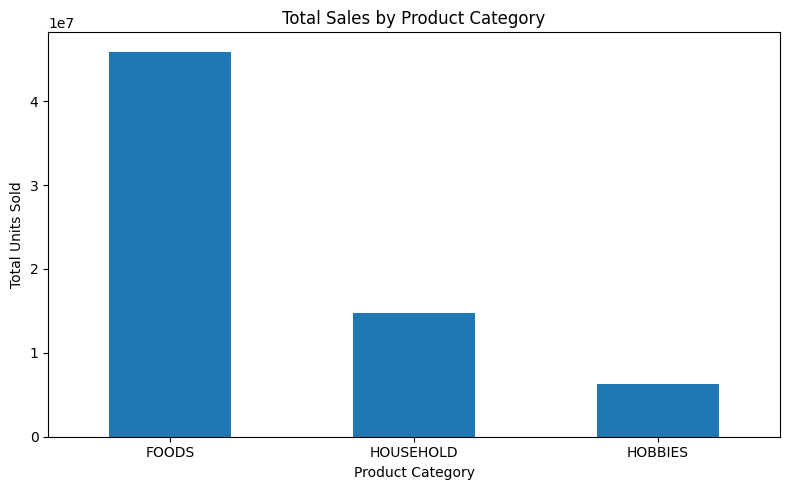

In [69]:
ax = category_summary["total_sales"].plot(
    kind="bar",
    figsize=(8, 5),
)

ax.set_title("Total Sales by Product Category")
ax.set_xlabel("Product Category")
ax.set_ylabel("Total Units Sold")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [70]:
category_summary["coefficient_of_variation"] = (
    category_summary["std_daily_sales"]
    / category_summary["mean_daily_sales"]
)

category_summary[
    [
        "mean_daily_sales",
        "std_daily_sales",
        "coefficient_of_variation",
        "sales_share_pct",
    ]
].round(2)

,mean_daily_sales,std_daily_sales,coefficient_of_variation,sales_share_pct
cat_id,,,,
FOODS,2365.92,928.25,0.39,68.62
HOUSEHOLD,760.64,362.40,0.48,22.06
HOBBIES,321.52,133.65,0.42,9.32


### Category-level findings

Demand differs substantially across product categories. FOODS dominates
overall volume, accounting for approximately 68.6% of total unit sales,
followed by HOUSEHOLD at 22.1% and HOBBIES at 9.3%.

FOODS also exhibits the largest absolute variation in daily demand. However,
after adjusting for differences in demand scale using the coefficient of
variation, HOUSEHOLD shows the greatest relative variability (0.48),
compared with HOBBIES (0.42) and FOODS (0.39).

These differences suggest that forecasting performance should be evaluated
across individual store-category series rather than relying only on an
aggregate error metric, which could be dominated by the much larger FOODS
category.

## 3. Demand Over Time

We examine aggregate demand over time to identify long-term trends,
seasonality, unusual periods, and potential structural changes in the
historical series.

In [71]:
daily_sales = (
    data
    .groupby("date", as_index=False)["sales"]
    .sum()
)

daily_sales.head()

,date,sales
0,2011-01-29,32631
1,2011-01-30,31749
2,2011-01-31,23783
3,2011-02-01,25412
4,2011-02-02,19146


In [72]:
daily_sales["rolling_mean_28"] = (
    daily_sales["sales"]
    .rolling(
        window=28,
        min_periods=1,
    )
    .mean()
)

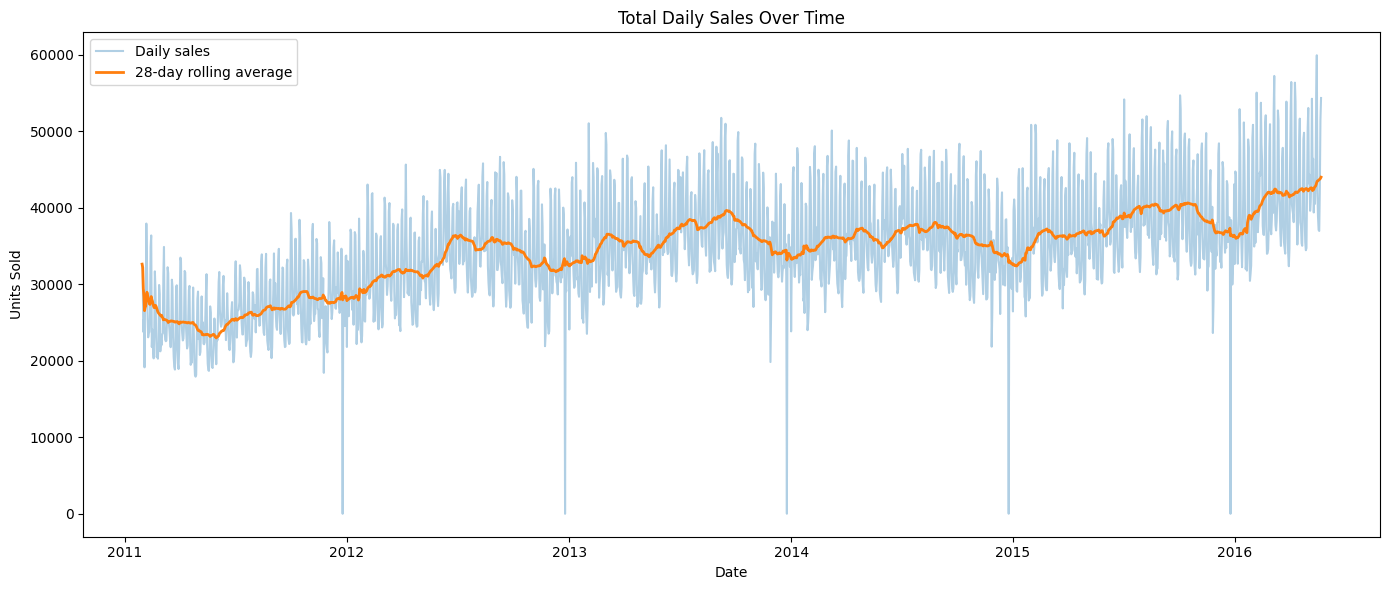

In [73]:
fig, ax = plt.subplots(
    figsize=(14, 6)
)

ax.plot(
    daily_sales["date"],
    daily_sales["sales"],
    alpha=0.35,
    label="Daily sales",
)

ax.plot(
    daily_sales["date"],
    daily_sales["rolling_mean_28"],
    linewidth=2,
    label="28-day rolling average",
)

ax.set_title("Total Daily Sales Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("Units Sold")
ax.legend()

plt.tight_layout()
plt.show()

### Time-series findings

Aggregate demand exhibits a clear long-term upward trend, indicating that
the demand process is non-stationary and that time-related features may be
important for forecasting.

The series also displays substantial short-term variation and recurring
patterns that may reflect weekly and annual seasonality. These patterns will
be examined separately using calendar-based aggregations.

Several unusually large demand drops occur at similar times across multiple
years. Rather than treating these observations as outliers, their relationship
with holidays and calendar events should be investigated before deciding how
they should be handled.

Absolute demand variability also appears to increase as the overall demand
level grows, motivating the use of scale-aware evaluation metrics in addition
to absolute-error measures.

In [74]:
low_demand_days = (
    daily_sales
    .nsmallest(15, "sales")
    [["date", "sales"]]
)

low_demand_days

,date,sales
696,2012-12-25,11
330,2011-12-25,13
1791,2015-12-25,14
1061,2013-12-25,20
1426,2014-12-25,20
88,2011-04-27,17929
87,2011-04-26,18113
89,2011-04-28,18145
299,2011-11-24,18427
110,2011-05-19,18684


In [75]:
low_demand_calendar = (
    low_demand_days
    .merge(
        calendar[
            [
                "date",
                "weekday",
                "event_name_1",
                "event_type_1",
                "event_name_2",
                "event_type_2",
            ]
        ].assign(
            date=lambda x: pd.to_datetime(x["date"])
        ),
        on="date",
        how="left",
    )
)

low_demand_calendar

,date,sales,weekday,event_name_1,event_type_1,event_name_2,event_type_2
0,2012-12-25,11,Tuesday,Christmas,National,NaN,NaN
1,2011-12-25,13,Sunday,Christmas,National,NaN,NaN
2,2015-12-25,14,Friday,Christmas,National,NaN,NaN
3,2013-12-25,20,Wednesday,Christmas,National,NaN,NaN
4,2014-12-25,20,Thursday,Christmas,National,NaN,NaN
5,2011-04-27,17929,Wednesday,NaN,NaN,NaN,NaN
6,2011-04-26,18113,Tuesday,Pesach End,Religious,NaN,NaN
7,2011-04-28,18145,Thursday,NaN,NaN,NaN,NaN
8,2011-11-24,18427,Thursday,Thanksgiving,National,NaN,NaN
9,2011-05-19,18684,Thursday,NaN,NaN,NaN,NaN


### Extreme-demand days

The most extreme demand drops are systematic rather than random outliers.
Christmas Day produces near-zero aggregate sales in every observed year,
with only 11–20 units sold across all store-category series. Thanksgiving
also appears among the lowest-demand days.

These observations should therefore be retained rather than removed as
outliers. Their recurring relationship with known calendar events provides
strong evidence for incorporating holiday and event information into the
forecasting feature set.

Several other low-demand observations occur during the early portion of the
dataset, when the overall demand level was lower. These observations are not
treated as anomalies without additional evidence.

## 4. Calendar and Seasonal Patterns

Demand is examined across recurring calendar periods to determine whether
systematic weekly and seasonal patterns can help explain short-term variation.

In [159]:
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

weekday_sales = (
    data
    .groupby("weekday", observed=True)["sales"]
    .mean()
    .reindex(weekday_order)
)

weekday_sales

weekday
Monday       1099.831047
Tuesday      1016.682792
Wednesday    1004.347292
Thursday     1010.701324
Friday       1145.249097
Saturday     1390.208993
Sunday       1376.801679
Name: sales, dtype: float64

In [160]:
weekday_index = (
    weekday_sales
    / data["sales"].mean()
    * 100
)

weekday_index.round(1)

weekday
Monday        95.7
Tuesday       88.5
Wednesday     87.4
Thursday      87.9
Friday        99.6
Saturday     121.0
Sunday       119.8
Name: sales, dtype: float64

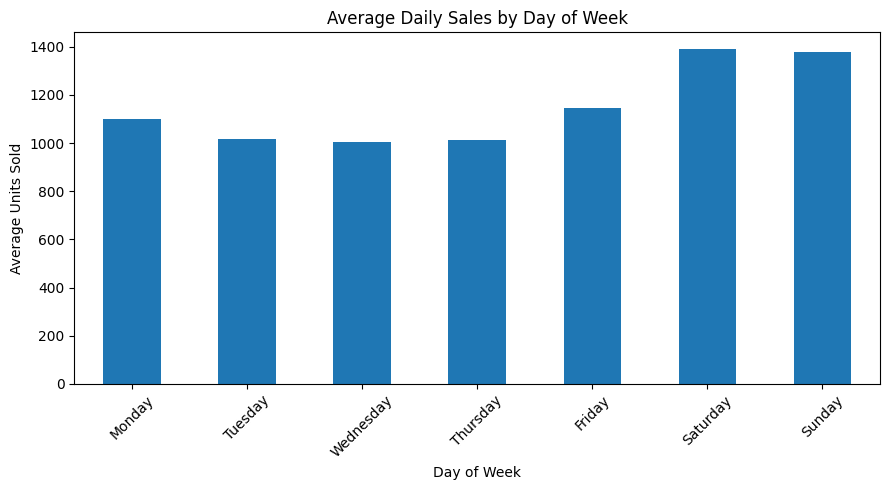

In [161]:
ax = weekday_sales.plot(
    kind="bar",
    figsize=(9, 5),
)

ax.set_title("Average Daily Sales by Day of Week")
ax.set_xlabel("Day of Week")
ax.set_ylabel("Average Units Sold")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Weekly seasonality

Demand exhibits a strong and systematic weekly pattern. Saturday and Sunday
have the highest average demand, approximately 21% and 20% above the overall
daily average, respectively.

In contrast, Tuesday through Thursday are approximately 12–13% below the
overall average, while Monday and Friday are closer to typical demand levels.

This pronounced weekly seasonality supports the inclusion of day-of-week
calendar features and weekly sales lags such as 7, 14, 21, 28, and 56 days
in the forecasting feature set.

In [162]:
monthly_sales = (
    data
    .groupby("month", observed=True)["sales"]
    .mean()
)

monthly_index = (
    monthly_sales
    / data["sales"].mean()
    * 100
)

monthly_index.round(1)

month
1      98.1
2     100.5
3      99.6
4      99.9
5      98.9
6     101.5
7     101.9
8     104.3
9     102.9
10    100.7
11     96.5
12     95.6
Name: sales, dtype: float64

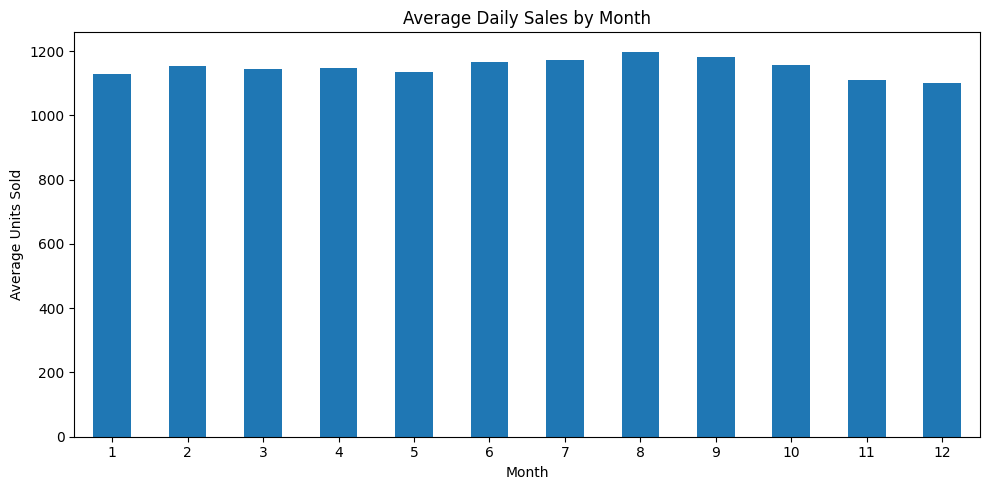

In [163]:
ax = monthly_sales.plot(
    kind="bar",
    figsize=(10, 5),
)

ax.set_title("Average Daily Sales by Month")
ax.set_xlabel("Month")
ax.set_ylabel("Average Units Sold")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [164]:
year_month_sales = (
    data
    .groupby(
        ["year", "month"],
        observed=True,
    )["sales"]
    .mean()
    .reset_index()
)

year_month_sales.head()

,year,month,sales
0,2011,1,979.588889
1,2011,2,864.732143
2,2011,3,821.039785
3,2011,4,819.681111
4,2011,5,773.722581


In [165]:
year_month_pivot = (
    year_month_sales
    .pivot(
        index="month",
        columns="year",
        values="sales",
    )
)

year_month_pivot.round(0)

year,2011,2012,2013,2014,2015,2016
month,,,,,,
1,980.0,961.0,1084.0,1137.0,1165.0,1307.0
2,865.0,1032.0,1203.0,1202.0,1228.0,1394.0
3,821.0,1061.0,1202.0,1208.0,1204.0,1372.0
4,820.0,1050.0,1149.0,1227.0,1215.0,1426.0
5,774.0,1073.0,1156.0,1175.0,1240.0,1508.0
6,837.0,1217.0,1262.0,1233.0,1284.0,NaN
7,882.0,1162.0,1247.0,1238.0,1325.0,NaN
8,888.0,1186.0,1295.0,1273.0,1349.0,NaN
9,904.0,1183.0,1296.0,1209.0,1321.0,NaN


In [166]:
year_month_index = (
    year_month_pivot
    .div(
        year_month_pivot.mean(axis=0),
        axis=1,
    )
    * 100
)

year_month_index.round(1)

year,2011,2012,2013,2014,2015,2016
month,,,,,,
1,110.9,87.4,90.4,95.1,92.4,93.3
2,97.9,94.0,100.3,100.5,97.5,99.5
3,92.9,96.6,100.2,101.1,95.5,97.9
4,92.8,95.6,95.8,102.6,96.4,101.8
5,87.6,97.7,96.3,98.3,98.4,107.6
6,94.7,110.8,105.2,103.2,101.9,NaN
7,99.8,105.8,103.9,103.6,105.1,NaN
8,100.5,107.9,108.0,106.5,107.0,NaN
9,102.3,107.7,108.0,101.1,104.8,NaN


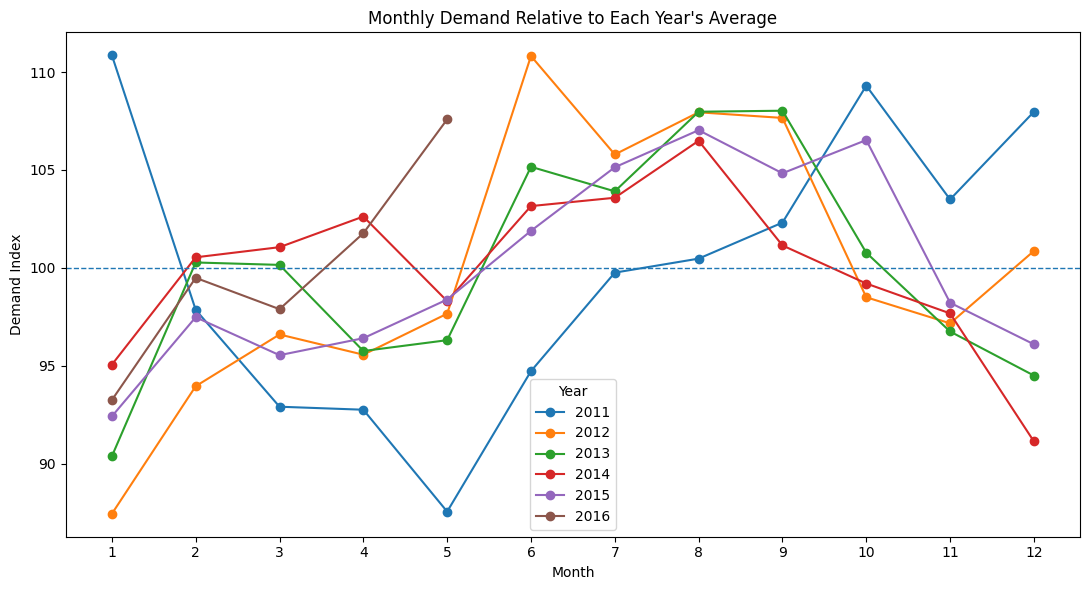

In [167]:
ax = year_month_index.plot(
    figsize=(11, 6),
    marker="o",
)

ax.axhline(
    100,
    linestyle="--",
    linewidth=1,
)

ax.set_title("Monthly Demand Relative to Each Year's Average")
ax.set_xlabel("Month")
ax.set_ylabel("Demand Index")
ax.legend(title="Year")

plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

### Monthly seasonality

Monthly demand shows evidence of annual seasonality, although the pattern is
less consistent than the weekly cycle. Across several complete years, demand
tends to strengthen during the summer and early fall, particularly around
June through September, while the early months of the year are often below
the annual average.

The magnitude and timing of these effects vary across years, indicating that
month alone does not fully explain the longer-term fluctuations in demand.
This variability supports representing annual timing through calendar and
cyclical features rather than assuming a fixed monthly seasonal adjustment.

The 2016 series is incomplete because the dataset ends in May, so its
within-year index is not directly comparable with the complete calendar years.

In [168]:
state_summary = (
    data
    .groupby(
        "state_id",
        observed=True,
    )["sales"]
    .agg(
        total_sales="sum",
        mean_daily_sales="mean",
        std_daily_sales="std",
    )
)

state_summary["sales_share_pct"] = (
    state_summary["total_sales"]
    / state_summary["total_sales"].sum()
    * 100
)

state_summary["coefficient_of_variation"] = (
    state_summary["std_daily_sales"]
    / state_summary["mean_daily_sales"]
)

state_summary.round(2)

,total_sales,mean_daily_sales,std_daily_sales,sales_share_pct,coefficient_of_variation
state_id,,,,,
CA,29196717,1253.51,1159.55,43.62,0.93
TX,19228405,1100.72,914.25,28.73,0.83
WI,18502051,1059.14,1021.53,27.65,0.96


In [169]:
store_summary = (
    data
    .groupby(
        ["state_id", "store_id"],
        observed=True,
    )["sales"]
    .agg(
        total_sales="sum",
        mean_daily_sales="mean",
        std_daily_sales="std",
    )
)

store_summary["coefficient_of_variation"] = (
    store_summary["std_daily_sales"]
    / store_summary["mean_daily_sales"]
)

store_summary.sort_values(
    "total_sales",
    ascending=False,
).round(2)

total_sales  mean_daily_sales  std_daily_sales  \
state_id store_id                                                   
CA       CA_3         11363540           1951.49          1540.09   
         CA_1          7832248           1345.05          1137.06   
TX       TX_2          7329642           1258.74          1048.56   
WI       WI_2          6697988           1150.26          1163.11   
         WI_3          6542557           1123.57          1056.53   
TX       TX_3          6205940           1065.76           864.71   
CA       CA_2          5818395            999.21           736.52   
TX       TX_1          5692823            977.64           786.95   
WI       WI_1          5261506            903.57           790.70   
CA       CA_4          4182534            718.28           569.96   

                   coefficient_of_variation  
state_id store_id                            
CA       CA_3                          0.79  
         CA_1                          0.85  
TX       TX_2                          0.83  
WI       WI_2                          1.01  
         WI_3                          0.94  
TX       TX_3                          0.81  
CA       CA_2                          0.74  
TX       TX_1                          0.80  
WI       WI_1                          0.88  
CA       CA_4                          0.79

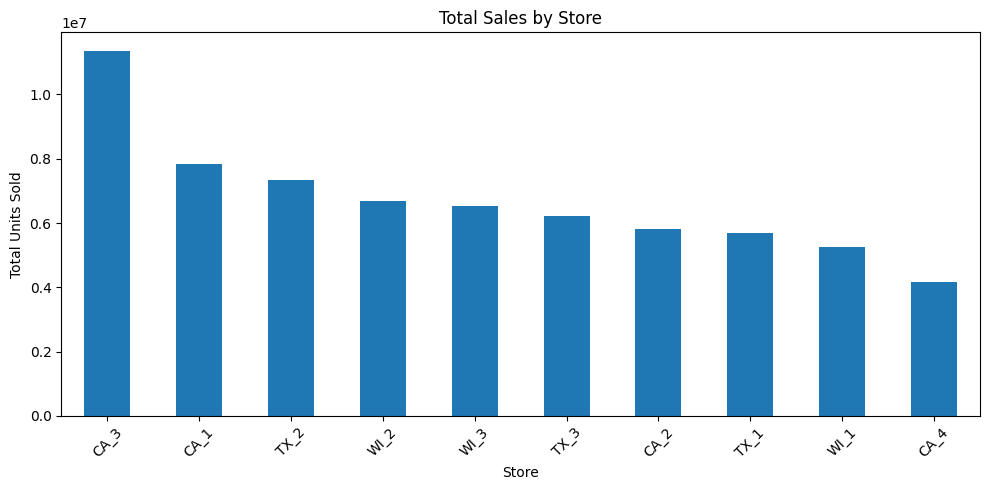

In [170]:
store_totals = (
    data
    .groupby(
        "store_id",
        observed=True,
    )["sales"]
    .sum()
    .sort_values(ascending=False)
)

ax = store_totals.plot(
    kind="bar",
    figsize=(10, 5),
)

ax.set_title("Total Sales by Store")
ax.set_xlabel("Store")
ax.set_ylabel("Total Units Sold")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Store-level demand differences

Demand varies substantially across stores in both scale and relative
variability. CA_3 has the highest overall demand, with average daily
store-category sales of approximately 1,951 units, while CA_4 averages
approximately 718 units.

Differences are also evident after accounting for scale. The coefficient of
variation ranges from approximately 0.74 for CA_2 to 1.01 for WI_2,
indicating that some stores experience substantially greater demand
variability relative to their typical sales level.

These differences support retaining store identity in the forecasting
problem rather than aggregating demand across locations. Forecast accuracy
should also be examined across individual store-category series to ensure
that aggregate performance does not conceal poorly performing locations.

At the state level, California accounts for the largest share of demand
(43.6%), followed by Texas (28.7%) and Wisconsin (27.7%). California also
has the highest average daily store-category demand.

Relative variability differs across states as well. Wisconsin has the
highest coefficient of variation (0.96), while Texas has the lowest (0.83).
Together with the store-level results, these differences indicate meaningful
geographic heterogeneity in both demand scale and variability.

In [171]:
data_eda = data.copy()

data_eda["snap"] = 0

data_eda.loc[
    data_eda["state_id"] == "CA",
    "snap"
] = data_eda.loc[
    data_eda["state_id"] == "CA",
    "snap_CA"
]

data_eda.loc[
    data_eda["state_id"] == "TX",
    "snap"
] = data_eda.loc[
    data_eda["state_id"] == "TX",
    "snap_TX"
]

data_eda.loc[
    data_eda["state_id"] == "WI",
    "snap"
] = data_eda.loc[
    data_eda["state_id"] == "WI",
    "snap_WI"
]

In [172]:
snap_summary = (
    data_eda
    .groupby(
        ["state_id", "snap"],
        observed=True,
    )["sales"]
    .agg(
        mean_sales="mean",
        median_sales="median",
        count="size",
    )
    .reset_index()
)

snap_summary.round(2)

,state_id,snap,mean_sales,median_sales,count
0,CA,0,1221.48,738.0,15612
1,CA,1,1318.62,769.5,7680
2,TX,0,1060.43,746.0,11709
3,TX,1,1182.61,771.0,5760
4,WI,0,988.06,606.0,11709
5,WI,1,1203.63,634.5,5760


In [173]:
snap_comparison = (
    snap_summary
    .pivot(
        index="state_id",
        columns="snap",
        values="mean_sales",
    )
    .rename(
        columns={
            0: "non_snap_mean",
            1: "snap_mean",
        }
    )
)

snap_comparison["difference_pct"] = (
    (
        snap_comparison["snap_mean"]
        / snap_comparison["non_snap_mean"]
    )
    - 1
) * 100

snap_comparison.round(2)

snap,non_snap_mean,snap_mean,difference_pct
state_id,,,
CA,1221.48,1318.62,7.95
TX,1060.43,1182.61,11.52
WI,988.06,1203.63,21.82


In [174]:
price_sales_correlation = (
    data
    .groupby(
        "cat_id",
        observed=True,
    )
    .apply(
        lambda x: x[
            ["avg_sell_price", "sales"]
        ].corr().iloc[0, 1],
        include_groups=False,
    )
    .rename("correlation")
)

price_sales_correlation.round(3)

cat_id
FOODS        0.379
HOBBIES      0.239
HOUSEHOLD   -0.364
Name: correlation, dtype: float64

### Price-demand relationship

The relationship between average selling price and demand varies across
categories. FOODS and HOBBIES show modest positive correlations (0.38 and
0.24), while HOUSEHOLD shows a moderate negative correlation (-0.36).

These descriptive correlations should not be interpreted as causal price
elasticities. However, the category-specific relationships support retaining
price and recent price-change features in the forecasting models.

In [175]:
lag_correlations = {}

for lag in [1, 7, 14, 28, 56]:
    lag_correlations[f"lag_{lag}"] = (
        data
        .groupby(
            ["store_id", "cat_id"],
            observed=True,
        )["sales"]
        .apply(
            lambda s: s.corr(s.shift(lag))
        )
        .mean()
    )

pd.Series(
    lag_correlations,
    name="mean_correlation",
).round(3)

lag_1     0.622
lag_7     0.706
lag_14    0.669
lag_28    0.712
lag_56    0.647
Name: mean_correlation, dtype: float64

### Lag relationships

Historical sales are strongly associated with future demand across multiple
lag horizons. The strongest average correlations are observed at 28 days
(0.71) and 7 days (0.71), while 14-, 56-, and 1-day lags also show substantial
relationships.

The strong performance of weekly and four-week lags is consistent with the
weekly seasonality observed earlier and supports the inclusion of multiple
weekly lag features in the forecasting models.

In [176]:
zero_ratio = (
    data
    .groupby(
        "cat_id",
        observed=True,
    )["sales"]
    .apply(lambda x: (x == 0).mean() * 100)
)

zero_ratio.round(2)

cat_id
FOODS        0.12
HOBBIES      0.26
HOUSEHOLD    0.26
Name: sales, dtype: float64

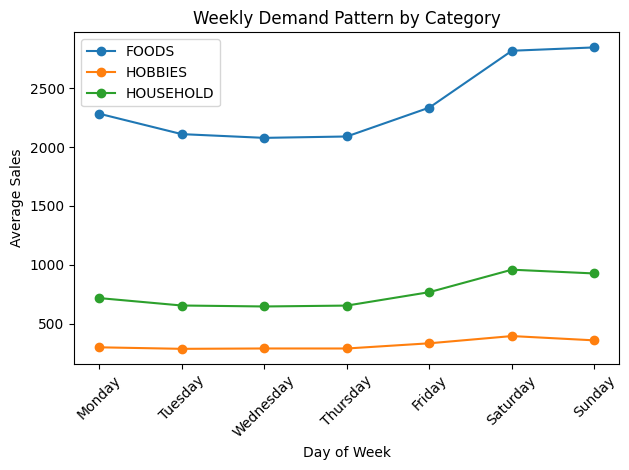

In [177]:
weekday_category = (
    data
    .groupby(
        ["weekday", "cat_id"],
        observed=True,
    )["sales"]
    .mean()
    .reset_index()
)

weekday_category["weekday"] = pd.Categorical(
    weekday_category["weekday"],
    categories=weekday_order,
    ordered=True,
)

weekday_category = weekday_category.sort_values("weekday")

for category in weekday_category["cat_id"].unique():
    subset = weekday_category[
        weekday_category["cat_id"] == category
    ]

    plt.plot(
        subset["weekday"],
        subset["sales"],
        marker="o",
        label=category,
    )

plt.title("Weekly Demand Pattern by Category")
plt.xlabel("Day of Week")
plt.ylabel("Average Sales")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

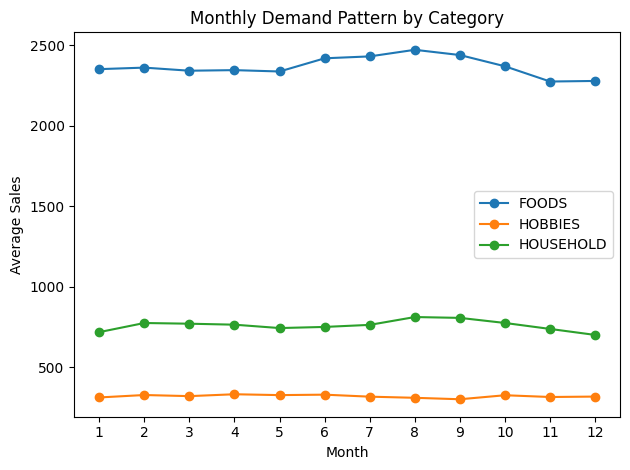

In [178]:
monthly_category = (
    data
    .groupby(
        ["month", "cat_id"],
        observed=True,
    )["sales"]
    .mean()
    .reset_index()
)

for category in monthly_category["cat_id"].unique():
    subset = monthly_category[
        monthly_category["cat_id"] == category
    ]

    plt.plot(
        subset["month"],
        subset["sales"],
        marker="o",
        label=category,
    )

plt.title("Monthly Demand Pattern by Category")
plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.xticks(range(1, 13))
plt.legend()
plt.tight_layout()
plt.show()

In [179]:
event_summary = (
    data
    .dropna(subset=["event_type_1"])
    .groupby(
        "event_type_1",
        observed=True,
    )["sales"]
    .mean()
    .sort_values(ascending=False)
)

event_summary.round(2)

event_type_1
Sporting     1193.20
Cultural     1157.29
Religious    1147.54
National      981.95
Name: sales, dtype: float64

### Calendar seasonality

Weekly seasonality is clearly visible across all three product categories.
Demand generally declines from Monday through midweek before increasing on
Friday and reaching its highest levels during the weekend. The weekend effect
is particularly pronounced for FOODS.

Monthly patterns are weaker than the weekly cycle. FOODS and HOUSEHOLD show
somewhat higher demand during the summer and early fall, while HOBBIES remains
relatively stable throughout the year. This supports the use of flexible
calendar and cyclical features rather than assuming a single fixed seasonal
pattern across categories.

### Demand distribution

Demand is right-skewed, with average daily store-category sales exceeding the
median. However, zero-demand observations are rare at this aggregation level:
approximately 0.12% for FOODS and 0.26% for both HOBBIES and HOUSEHOLD.

Demand at the store-category level is therefore largely continuous rather
than intermittent, supporting the use of standard regression-based
forecasting methods.

### Event effects

Demand differs across calendar event types. Sporting, cultural, and religious
events have average demand near or slightly above typical levels, while
national events have substantially lower average demand.

Investigation of extreme low-demand days shows that Christmas produces
near-zero sales in every observed year. These recurring observations represent
meaningful calendar effects rather than random outliers and support retaining
event information as forecasting features.